In [78]:
import json
import pymysql
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pymongo import MongoClient

In [25]:
def get_local():
    with open("../auth.json", "r") as f:
        auth = json.load(f)["local"]
        uri = f'mongodb://{auth["username"]}:{auth["password"]}@{auth["host"]}:{auth["port"]}/{auth["database"]}'
        conn = MongoClient(uri)[auth["database"]]
    return conn

def get_remote():
    with open("../auth.json", "r") as f:
        auth = json.load(f)["remote"]
        conn = pymysql.connect(
            host=auth["host"], port=auth["port"], user=auth["username"], password=auth["password"],
            database=auth["database"], charset=auth["charset"], cursorclass=pymysql.cursors.DictCursor
       )
    return conn

In [26]:
remote = get_remote()

### MPM310

In [27]:
sql = f'SELECT * FROM Mpm310 WHERE farmid = "0003" ORDER BY rcvtime ASC;'

In [28]:
with remote.cursor() as cursor:
    cursor.execute(sql)
    results = cursor.fetchall()

In [29]:
mpm310 = pd.DataFrame(list(results))

In [34]:
# 1. rcvtime을 datetime으로 변환
mpm310["rcv_dt"] = pd.to_datetime(
    mpm310["rcvtime"].astype(str),
    format="%Y%m%d%H%M%S"
)

# 2. 시간순 정렬
mpm310 = mpm310.sort_values("rcv_dt").reset_index(drop=True)

# 3. 이전 수집 시각과의 차이 계산
mpm310["prev_rcv_dt"] = mpm310["rcv_dt"].shift(1)
mpm310["gap"] = mpm310["rcv_dt"] - mpm310["prev_rcv_dt"]

# 4. 크게 빈 구간만 추출
# 예: 10분 이상 비면 수집 공백으로 판단
gap_threshold = pd.Timedelta(minutes=10)

gaps = mpm310[mpm310["gap"] >= gap_threshold].copy()

# 5. 보기 좋게 정리
gaps_result = gaps[[
    "prev_rcv_dt",
    "rcv_dt",
    "gap",
    "devid",
    "farmid"
]].rename(columns={
    "prev_rcv_dt": "gap_start",
    "rcv_dt": "gap_end",
    "gap": "gap_duration"
})

print(gaps_result)

Empty DataFrame
Columns: [gap_start, gap_end, gap_duration, devid, farmid]
Index: []


In [39]:
mpm310["gap"].max()

Timedelta('0 days 00:05:10')

In [40]:
mpm310

,devid,rcvtime,farmid,voltage,current,activepower,reactivepower,apparentpower,frequency,powerfactor,actelectric,reaelectric,peakactive,peakcurrent,rcv_dt,prev_rcv_dt,gap
0,5,20260101000038,0003,222.53,0.00,0.00,0.00,0.00,60.0,0.00,0,0,0.000,0.000,2026-01-01 00:00:38,NaT,NaT
1,7,20260101000040,0003,0.00,0.00,0.00,0.00,0.00,0.0,0.00,277,160,0.519,4.113,2026-01-01 00:00:40,2026-01-01 00:00:38,0 days 00:00:02
2,6,20260101000051,0003,0.00,0.00,0.00,0.00,0.00,0.0,0.00,516,547,1.038,7.290,2026-01-01 00:00:51,2026-01-01 00:00:40,0 days 00:00:11
3,8,20260101000052,0003,0.00,0.00,0.00,0.00,0.00,0.0,0.00,152,39,0.675,4.974,2026-01-01 00:00:52,2026-01-01 00:00:51,0 days 00:00:01
4,1,20260101000055,0003,220.65,0.00,0.00,0.00,0.00,60.0,0.00,545,25,0.864,4.146,2026-01-01 00:00:55,2026-01-01 00:00:52,0 days 00:00:03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456334,8,20260601151843,0003,220.13,0.00,0.00,0.00,0.00,59.9,0.00,902,190,0.699,4.974,2026-06-01 15:18:43,2026-06-01 15:18:42,0 days 00:00:01
1456335,1,20260601151847,0003,212.80,2.01,0.43,0.02,0.43,60.0,1.00,1089,55,0.864,4.146,2026-06-01 15:18:47,2026-06-01 15:18:43,0 days 00:00:04
1456336,2,20260601151848,0003,219.93,3.35,0.67,0.12,0.68,59.9,0.98,1826,375,0.927,4.764,2026-06-01 15:18:48,2026-06-01 15:18:47,0 days 00:00:01
1456337,3,20260601151849,0003,219.25,1.65,0.35,0.04,0.35,59.9,0.99,1477,117,0.675,4.542,2026-06-01 15:18:49,2026-06-01 15:18:48,0 days 00:00:01


In [42]:
mpm310["gap"].max()

Timedelta('0 days 00:05:10')

#### mpm310 - total values

In [89]:
df_310 = mpm310[["rcv_dt", "activepower", "devid"]].copy()
df_310["rcv_h"] = df_310["rcv_dt"].dt.strftime("%Y%m%d-%H")
df_310["activepower_60"] = df_310["activepower"] / 60
df_310

,rcv_dt,activepower,devid,rcv_h,activepower_60
0,2026-01-01 00:00:38,0.00,5,20260101-00,0.00
1,2026-01-01 00:00:40,0.00,7,20260101-00,0.00
2,2026-01-01 00:00:51,0.00,6,20260101-00,0.00
3,2026-01-01 00:00:52,0.00,8,20260101-00,0.00
4,2026-01-01 00:00:55,0.00,1,20260101-00,0.00
...,...,...,...,...,...
1456334,2026-06-01 15:18:43,0.00,8,20260601-15,0.00
1456335,2026-06-01 15:18:47,0.43,1,20260601-15,0.007166666666666666666666666667
1456336,2026-06-01 15:18:48,0.67,2,20260601-15,0.01116666666666666666666666667
1456337,2026-06-01 15:18:49,0.35,3,20260601-15,0.005833333333333333333333333333


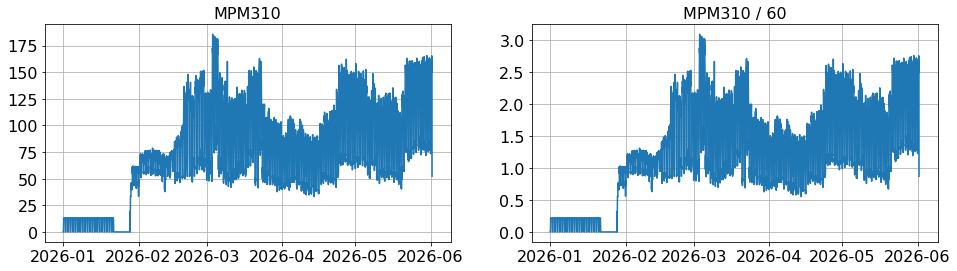

In [105]:
agg_310 = df_310.groupby("rcv_h")[["activepower", "activepower_60"]].sum()

dates = pd.to_datetime(agg_310.index, format="%Y%m%d-%H")

plt.figure(figsize=(16, 4))

plt.subplot(1, 2, 1)
plt.plot(dates, agg_310["activepower"].values)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True)
plt.title("MPM310", fontsize=16)

plt.subplot(1, 2, 2)
plt.plot(dates, agg_310["activepower_60"].values)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True)
plt.title("MPM310 / 60", fontsize=16)

plt.show()

## MPM330

In [51]:
sql = f'SELECT * FROM Mpm330 WHERE farmid = "0003" ORDER BY rcvtime ASC;'

In [52]:
with remote.cursor() as cursor:
    cursor.execute(sql)
    results = cursor.fetchall()

In [53]:
mpm330 = pd.DataFrame(list(results))

In [54]:
# 1. rcvtime을 datetime으로 변환
mpm330["rcv_dt"] = pd.to_datetime(
    mpm330["rcvtime"].astype(str),
    format="%Y%m%d%H%M%S"
)

# 2. 시간순 정렬
mpm330 = mpm330.sort_values("rcv_dt").reset_index(drop=True)

# 3. 이전 수집 시각과의 차이 계산
mpm330["prev_rcv_dt"] = mpm330["rcv_dt"].shift(1)
mpm330["gap"] = mpm330["rcv_dt"] - mpm330["prev_rcv_dt"]

# 4. 크게 빈 구간만 추출
# 예: 10분 이상 비면 수집 공백으로 판단
gap_threshold = pd.Timedelta(minutes=10)

gaps = mpm330[mpm330["gap"] >= gap_threshold].copy()

# 5. 보기 좋게 정리
gaps_result = gaps[[
    "prev_rcv_dt",
    "rcv_dt",
    "gap",
    "devid",
    "farmid"
]].rename(columns={
    "prev_rcv_dt": "gap_start",
    "rcv_dt": "gap_end",
    "gap": "gap_duration"
})

print(gaps_result)

                 gap_start             gap_end    gap_duration  devid farmid
112587 2026-03-28 21:16:21 2026-03-28 21:26:48 0 days 00:10:27      8   0003
113674 2026-03-30 02:02:20 2026-03-30 02:12:58 0 days 00:10:38      8   0003
116453 2026-04-02 02:55:23 2026-04-02 03:06:54 0 days 00:11:31      8   0003
125979 2026-04-12 13:03:09 2026-04-12 13:13:59 0 days 00:10:50      8   0003
127025 2026-04-13 17:59:52 2026-04-13 18:12:06 0 days 00:12:14      8   0003
128111 2026-04-14 23:52:33 2026-04-15 00:04:37 0 days 00:12:04      8   0003


In [56]:
gaps_result

,gap_start,gap_end,gap_duration,devid,farmid
112587,2026-03-28 21:16:21,2026-03-28 21:26:48,0 days 00:10:27,8,0003
113674,2026-03-30 02:02:20,2026-03-30 02:12:58,0 days 00:10:38,8,0003
116453,2026-04-02 02:55:23,2026-04-02 03:06:54,0 days 00:11:31,8,0003
125979,2026-04-12 13:03:09,2026-04-12 13:13:59,0 days 00:10:50,8,0003
127025,2026-04-13 17:59:52,2026-04-13 18:12:06,0 days 00:12:14,8,0003
128111,2026-04-14 23:52:33,2026-04-15 00:04:37,0 days 00:12:04,8,0003


In [55]:
mpm330

,devid,rcvtime,farmid,rsvoltage,stvoltage,trvoltage,rvoltage,svoltage,tvoltage,rcurrent,...,trepower,rappower,sappower,tappower,rpowerfactor,spowerfactor,tpowerfactor,rcv_dt,prev_rcv_dt,gap
0,8,20260101000053,0003,381.84,381.94,379.98,219.32,221.60,219.45,0.000,...,0.000,0.000,0.000,0.000,0.00,0.00,75.78,2026-01-01 00:00:53,NaT,NaT
1,8,20260101000147,0003,381.98,381.84,380.24,219.62,221.47,219.45,0.000,...,0.000,0.000,0.000,0.000,0.00,0.00,143.46,2026-01-01 00:01:47,2026-01-01 00:00:53,0 days 00:00:54
2,8,20260101000240,0003,381.98,381.78,380.40,219.75,221.34,219.53,0.000,...,0.000,0.000,0.000,0.000,0.00,0.00,366.78,2026-01-01 00:02:40,2026-01-01 00:01:47,0 days 00:00:53
3,8,20260101000342,0003,382.44,382.40,380.46,219.69,221.92,219.65,0.000,...,0.000,0.000,0.000,0.000,0.00,0.00,329.04,2026-01-01 00:03:42,2026-01-01 00:02:40,0 days 00:01:02
4,8,20260101000454,0003,382.60,382.68,380.94,219.91,221.91,219.99,0.000,...,0.000,0.000,0.000,0.000,0.00,0.00,417.86,2026-01-01 00:04:54,2026-01-01 00:03:42,0 days 00:01:12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
184980,8,20260601151455,0003,376.10,378.60,373.68,214.31,219.99,217.20,1.992,...,-0.078,0.424,0.294,0.408,654.38,654.45,2.86,2026-06-01 15:14:55,2026-06-01 15:13:52,0 days 00:01:03
184981,8,20260601151557,0003,376.54,379.08,374.08,214.50,220.29,217.45,1.650,...,-0.060,0.354,0.348,0.458,654.36,654.42,428.31,2026-06-01 15:15:57,2026-06-01 15:14:55,0 days 00:01:02
184982,8,20260601151659,0003,376.04,378.50,374.08,214.56,219.66,217.40,1.764,...,-0.066,0.378,0.350,0.484,654.36,654.40,219.92,2026-06-01 15:16:59,2026-06-01 15:15:57,0 days 00:01:02
184983,8,20260601151751,0003,376.22,378.64,374.14,214.61,219.81,217.42,1.758,...,-0.060,0.378,0.358,0.488,654.36,654.41,424.62,2026-06-01 15:17:51,2026-06-01 15:16:59,0 days 00:00:52


In [57]:
mpm330["gap"].max()

Timedelta('0 days 00:12:14')

In [98]:
df_330 = mpm330[["rcv_dt", "totalacpower", "devid"]].copy()
df_330["rcv_h"] = df_330["rcv_dt"].dt.strftime("%Y%m%d-%H")
df_330["activepower_60"] = df_330["totalacpower"] / 60
df_330

,rcv_dt,totalacpower,devid,rcv_h,activepower_60
0,2026-01-01 00:00:53,0.000,8,20260101-00,0.000
1,2026-01-01 00:01:47,0.000,8,20260101-00,0.000
2,2026-01-01 00:02:40,0.000,8,20260101-00,0.000
3,2026-01-01 00:03:42,0.000,8,20260101-00,0.000
4,2026-01-01 00:04:54,0.000,8,20260101-00,0.000
...,...,...,...,...,...
184980,2026-06-01 15:14:55,1.098,8,20260601-15,0.0183
184981,2026-06-01 15:15:57,1.146,8,20260601-15,0.0191
184982,2026-06-01 15:16:59,1.200,8,20260601-15,0.020
184983,2026-06-01 15:17:51,1.206,8,20260601-15,0.0201


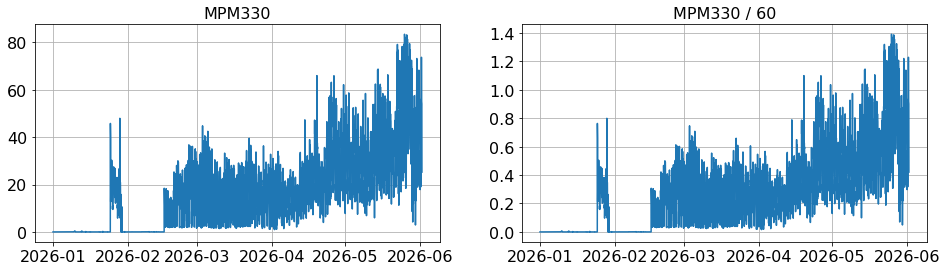

In [103]:
agg_330 = df_330.groupby("rcv_h")[["totalacpower", "activepower_60"]].sum()

dates = pd.to_datetime(agg_330.index, format="%Y%m%d-%H")

plt.figure(figsize=(16, 4))

plt.subplot(1, 2, 1)
plt.plot(dates, agg_330["totalacpower"].values)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.title("MPM330", fontsize=16)
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(dates, agg_330["activepower_60"].values)
plt.title("MPM330 / 60", fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True)

plt.show()